In [ ]:
pip install gymnasium

In [18]:
import gymnasium as gym
import numpy as np
import random


you can change n(frozen lake size) if you want.
also the code is in deterministic mode now. change it if you want.

In [19]:
import gymnasium as gym
import numpy as np
import random
import time
from IPython.display import clear_output
from gymnasium.envs.toy_text.frozen_lake import generate_random_map



# 1. User-defined settings
map_size = 5                 # side length of the lake grid
num_episodes = 10000         # how many training runs
max_steps = 200              # max moves per episode
alpha = 0.1                  # learning rate (0 < α ≤ 1)
gamma = 0.99                 # discount factor (0 < γ ≤ 1)
epsilon = 1.0                # initial exploration rate
epsilon_min = 0.01          # minimum exploration rate
epsilon_decay = 0.01        # how fast exploration drops each episode

# 2. Build the environment (non-slippery)
lake_map = generate_random_map(size=map_size)
env = gym.make(
    "FrozenLake-v1",
    desc=lake_map,
    is_slippery=False,
    render_mode="ansi"
)

# 3. Initialize Q-table: rows = states, columns = actions
n_states = env.observation_space.n
n_actions = env.action_space.n
q_table = np.zeros((n_states, n_actions))

# ------------------------------------------------------------------
# Training loop: play num_episodes of FrozenLake, updating Q-values
# ------------------------------------------------------------------
for episode in range(num_episodes):
    state, _ = env.reset()
    for step in range(max_steps):
        # 3.1 Choose action: explore vs. exploit
        if random.random() < epsilon:
            action = env.action_space.sample()  # explore random action
        else:
            action = np.argmax(q_table[state])  # exploit best-known action

        # 3.2 Take the action and observe the outcome
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # 3.3 Q-learning update rule
        td_target = reward + gamma * np.max(q_table[next_state])
        td_error = td_target - q_table[state, action]
        q_table[state, action] += alpha * td_error

        state = next_state
        if done:
            break

    # 3.4 Decay exploration rate (to use exploitation more over time)
    epsilon = max(epsilon_min, epsilon * (1 - epsilon_decay))

# ------------------------------------------------------------------
# Show final Q-table
# ------------------------------------------------------------------
print("Trained Q-table:")
print(q_table)

# ------------------------------------------------------------------
# 4. Visual replay: watch 3 episodes using learned policy
# ------------------------------------------------------------------
for run in range(1, 4):
    state, _ = env.reset()
    print(f"\nReplay Episode {run}")
    time.sleep(1)
    for _ in range(max_steps):
        clear_output(wait=True)
        print(env.render())
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        time.sleep(0.5)
        if done:
            clear_output(wait=True)
            print(env.render())
            msg = "Goal reached! ✅" if reward == 1 else "Fell into a hole. ❌"
            print(msg)
            time.sleep(2)
            break

# ------------------------------------------------------------------
# 5. Quantitative evaluation: calculate success rate
# ------------------------------------------------------------------
test_episodes = 100
successes = 0
for _ in range(test_episodes := test_episodes if 'test_episodes' in locals() else 100):
    state, _ = env.reset()
    for _ in range(max_steps):
        action = np.argmax(q_table[state])
        state, reward, terminated, truncated, _ = env.step(action)
        if terminated or truncated:
            successes += reward  # reward=1 if reached goal
            break

success_rate = successes / test_episodes * 100
print(f"\nOverall Success Rate: {success_rate:.2f}% over {test_episodes} episodes")

env.close()


  (Right)
SFFFF
FFHFF
FFFFF
FFFFF
HFFFG

 Goal reached!

✅ Success rate: 100.00% over 100 episodes




---



This script runs Q-learning on a customizable Frozen Lake map.
 We sweep through different learning rates, discount factors, and
 epsilon decay rates, comparing slippery vs. non-slippery lakes.
 Finally, it plots how each parameter set affects the success rate.

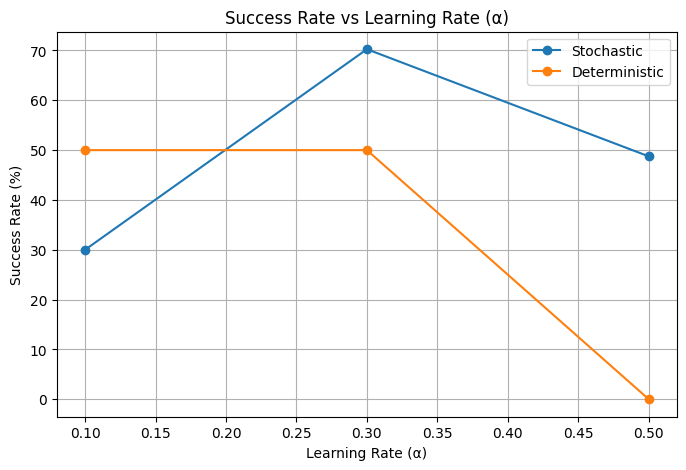

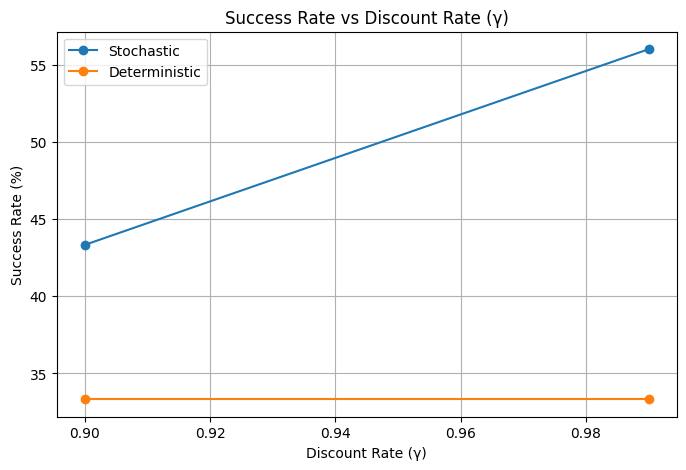

In [ ]:
import gymnasium as gym
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
from gymnasium.envs.toy_text.frozen_lake import generate_random_map


# 1) Experiment settings
map_size = 5               # side length of the square lake
learning_rates = [0.1, 0.3, 0.5]
discount_factors = [0.9, 0.99]
epsilon_decays = [0.99, 0.995]
environment_types = [True, False]  # True=slippery, False=deterministic

def run_q_learning(alpha, gamma, epsilon_decay, slippery):
    """
    Train a Q-learning agent on a random NxN FrozenLake and
    return the percent of successful runs.
    """
    # Create a random map and initialize the environment
    lake_map = generate_random_map(size=map_size)
    env = gym.make(
        "FrozenLake-v1",
        desc=lake_map,
        is_slippery=slippery,
        render_mode="ansi"
    )

    n_states = env.observation_space.n
    n_actions = env.action_space.n
    q_table = np.zeros((n_states, n_actions))

    # Q-learning parameters
    epsilon = 1.0
    min_epsilon = 0.01
    num_training_episodes = 10000
    max_steps_per_episode = 100

    # Training phase
    for episode in range(num_training_episodes):
        state, _ = env.reset()
        for _ in range(max_steps_per_episode):
            # Decide: explore or exploit
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(q_table[state])

            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated

            # Q-learning update rule
            td_target = reward + gamma * np.max(q_table[next_state])
            td_error = td_target - q_table[state, action]
            q_table[state, action] += alpha * td_error

            state = next_state
            if done:
                break

        # Gradually reduce exploration
        epsilon = max(min_epsilon, epsilon * epsilon_decay)

    # Evaluation phase
    num_test_episodes = 100
    successes = 0
    for _ in range(num_test_episodes):
        state, _ = env.reset()
        for _ in range(max_steps_per_episode):
            action = np.argmax(q_table[state])
            state, reward, terminated, truncated, _ = env.step(action)
            if terminated or truncated:
                successes += reward  # 1 if reached goal
                break

    env.close()
    return (successes / num_test_episodes) * 100

# 2) Run experiments and collect results
results = []
for slippery in environment_types:
    env_label = "Stochastic" if slippery else "Deterministic"
    for alpha in learning_rates:
        for gamma in discount_factors:
            for decay in epsilon_decays:
                rate = run_q_learning(alpha, gamma, decay, slippery)
                results.append({
                    'Environment': env_label,
                    'Alpha': alpha,
                    'Gamma': gamma,
                    'EpsilonDecay': decay,
                    'SuccessRate': rate
                })

# 3) Convert to NumPy-friendly format for plotting
# Group by alpha (averaging over gamma and epsilon decay)
plot_data = {'Stochastic': {}, 'Deterministic': {}}
for entry in results:
    key = entry['Environment']
    alpha = entry['Alpha']
    plot_data[key].setdefault(alpha, []).append(entry['SuccessRate'])

# 4) Plot Success Rate vs Learning Rate
plt.figure(figsize=(8,5))
for env_label, alpha_dict in plot_data.items():
    alphas = sorted(alpha_dict.keys())
    avg_rates = [np.mean(alpha_dict[a]) for a in alphas]
    plt.plot(alphas, avg_rates, marker='o', label=env_label)

plt.title('Success Rate vs Learning Rate (α)')
plt.xlabel('Learning Rate (α)')
plt.ylabel('Success Rate (%)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


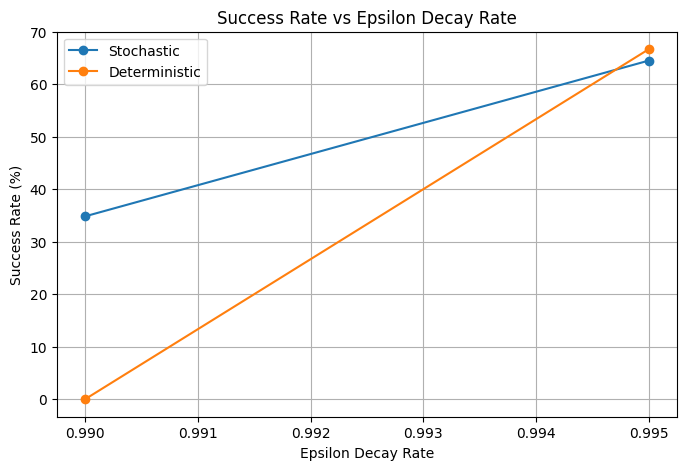

In [ ]:
# prompt: i want to do the plotting for epsilon as well

# Plotting Success Rate vs Epsilon Decay (averaged over Alpha and Gamma)
fig3, ax3 = plt.subplots(figsize=(8, 5))

for slippery in env_types:
    label = 'Stochastic' if slippery else 'Deterministic'
    subset = [r for r in results if r['slippery'] == label]
    # average over alpha and gamma
    avg_by_epsilon_decay = {}
    for ed in epsilon_decays:
        rates = [r['success_rate'] for r in subset if r['epsilon_decay'] == ed]
        avg_by_epsilon_decay[ed] = sum(rates) / len(rates) if rates else 0
    ax3.plot(
        list(avg_by_epsilon_decay.keys()),
        list(avg_by_epsilon_decay.values()),
        marker='o',
        label=label
    )
ax3.set_title('Success Rate vs Epsilon Decay Rate')
ax3.set_xlabel('Epsilon Decay Rate')
ax3.set_ylabel('Success Rate (%)')
ax3.legend()
ax3.grid(True)
plt.show()